# **Verification Lab2 - NLP Medical Question Filtering**


***
# Setup

## Imports

In [1]:
# General imports
import os
from datetime import datetime
import time
import copy

import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import uuid

# Plots
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Embedding
from sentence_transformers import SentenceTransformer

# Scikit Learn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Tensorflow, Keras
import tensorflow as tf 
import keras_tuner as kt


## Project Setup

In [2]:
# Project Setup
#

#---- Run Parameters --------------------------------
run_name = 'Test_Run_2'

#----------------------------------------------------

# Folder paths
local_project_folder = Path.cwd().parent
data_folder = local_project_folder.joinpath('Data')
if not data_folder.exists():
    raise FileNotFoundError(f'{data_folder} does not exist')
results_folder = local_project_folder.joinpath('Results')
if not results_folder.exists():
    raise FileNotFoundError(f'{results_folder} does not exist')

# Run Results
# run_name = f"Run_{run_name}_{datetime.now().strftime('%Y%m%d')}"
run_results_folder = results_folder.joinpath(f'{run_name}')
run_results_folder.mkdir(parents=True, exist_ok=True) 

del local_project_folder, results_folder

***
# Training Data Prepare

In [3]:
# Load the full dataset & split
# NB: Initial Train, Validate, Test split assuming no K-fold validation
#

# Load the saved dataset with query and embeddings
query_df = pd.read_pickle(run_results_folder.joinpath('query_data_embeddings.pkl'))

# Select features, X and target y
X = np.vstack(query_df['query-embedding'].values)
y = query_df['query-is-non-medical'].to_numpy().astype(np.float32)  # Convert bool to float32

# Ref for later mapping back to original query test
ref_ids = query_df['ref-id'].values

# Train, validate, test split 60:20:20
# NB: Classes are possibly imbalanced so use stratification
X_train, X_temp, y_train, y_temp, ids_train, ids_temp = train_test_split(X, y, ref_ids, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test, ids_val, ids_test = train_test_split(X_temp, y_temp, ids_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Full df shape: {query_df.shape}")
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")
print(f"Ref ids: {ref_ids.shape}")

del X, y, X_temp, y_temp, ids_temp

Full df shape: (2916, 5)
Training set: (1749, 384), (1749,)
Validation set: (583, 384), (583,)
Test set: (584, 384), (584,)
Ref ids: (2916,)


Dimensions. Train, val, test
Original 384 384 384
Reduced 30 30 30
Explained variance total: 0.4104


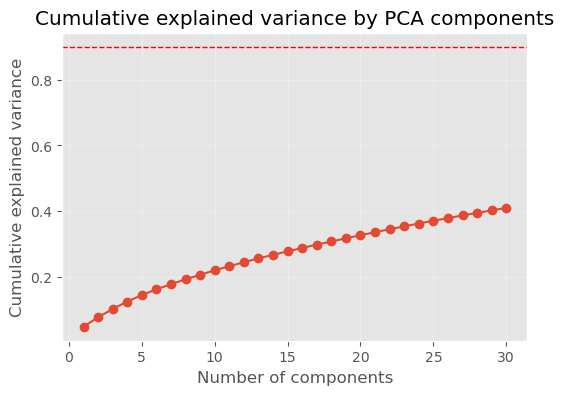

In [4]:
# PCA and Data Split
#

# TODO: Review PCA approach and use, eg ANTONIO combines ALL X and fits to that?!

# Repeatable Pipeline
pipe = Pipeline([
    ("center", StandardScaler(with_mean=True, with_std=False)),
    # ("pca", PCA(n_components=0.75, svd_solver="full", random_state=42)),
    ("pca", PCA(n_components=30, svd_solver="full", random_state=42)), # ?? this reduces to 41% explained variance ... but better model
])

# Fit to X_train and then transform val, test
X_train_pca = pipe.fit_transform(X_train)
X_val_pca = pipe.transform(X_val)
X_test_pca = pipe.transform(X_test)

print('Dimensions. Train, val, test')
print("Original", X_train.shape[1], X_val.shape[1], X_test.shape[1])
print("Reduced", X_train_pca.shape[1], X_val_pca.shape[1], X_test_pca.shape[1])
print(f'Explained variance total: {pipe.named_steps["pca"].explained_variance_ratio_.sum():.4f}')

cum_var = np.cumsum(pipe.named_steps["pca"].explained_variance_ratio_)
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--', linewidth=1)  # 90% threshold
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Cumulative explained variance by PCA components')
plt.grid(True, alpha=0.3)
plt.show()

# Save pipeline for later use with the NN model
# import joblib
# joblib.dump(pipe, "pca_embeddings_pipeline.joblib")
# Reload with NN model
# pipe = joblib.load("pca_embeddings_pipeline.joblib")
# X_new_pca = pipe.transform(X_new)

X_train = X_train_pca
X_val = X_val_pca
X_test = X_test_pca
del X_train_pca, X_val_pca, X_test_pca

In [5]:
# Put X,y data into more efficient tf datasets for training
#

embedding_dimensions = X_train.shape[1]
train_dataset_tf = tf.data.Dataset.from_tensor_slices((X_train, y_train.astype(np.float32)))
val_dataset_tf = tf.data.Dataset.from_tensor_slices((X_val, y_val.astype(np.float32)))
# test_dataset_tf = tf.data.Dataset.from_tensor_slices((X_test_pca, y_test.astype(np.float32)))

# Shuffle, batch etc to improve gradient descent, efficiency ...
buffer_size = len(X_train) + len(X_val) + len(X_test)
batch_size = 64

train_dataset_tf = train_dataset_tf.shuffle(buffer_size=buffer_size)
train_dataset_tf = train_dataset_tf.batch(batch_size)
val_dataset_tf = val_dataset_tf.batch(batch_size)
val_dataset_tf = val_dataset_tf.prefetch(1)
# test_dataset_tf = test_dataset_tf.batch(batch_size)
# test_dataset_tf = test_dataset_tf.prefetch(1)

print(train_dataset_tf)
print(val_dataset_tf)
# print(test_dataset_tf)

<_BatchDataset element_spec=(TensorSpec(shape=(None, 30), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 30), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


*** 
# Model Training - Clean

## Model Utility Functions

In [6]:
# Model Details
#

def inspect_model(model):

    print(f'\n{model.summary()}')    
    for i, layer in enumerate(model.layers):
        print(f"\nLayer {i}: {layer.name} ({type(layer).__name__})")
        print(f"  - Input shape: {layer.input_shape}")
        print(f"  - Output shape: {layer.output_shape}")
        
        # Show activation function for layers that have it
        if hasattr(layer, 'activation'):
            print(f"  - Activation: {layer.activation.__name__}")
            
        # Show units for Dense layers
        if hasattr(layer, 'units'):
            print(f"  - Units: {layer.units}")
            
        # Show other layer-specific attributes
        if hasattr(layer, 'kernel_initializer') and layer.kernel_initializer is not None:
            print(f"  - Kernel initializer: {layer.kernel_initializer.__class__.__name__}")
            
        # Show parameter count for this layer
        if hasattr(layer, 'count_params'):
            print(f"  - Parameters: {layer.count_params():,}")

In [7]:
# Model Evaluation
#

def evaluate_model(model, X, y, run_name, data_source='clean', verbose=True):

    # Model predictions
    start_time = time.perf_counter()
    y_pred_probs = model.predict(X)
    # y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    y_pred = np.argmax(y_pred_probs, axis=1) 
    duration = time.perf_counter() - start_time

    # Calculate Metrics
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = metrics.accuracy_score(y_true=y, y_pred=y_pred)
    recall = metrics.recall_score(y_true=y, y_pred=y_pred, pos_label=1)
    precision = metrics.precision_score(y_true=y, y_pred=y_pred, pos_label=1)
    f1_score = metrics.f1_score(y_true=y, y_pred=y_pred, pos_label=1)
    specificity = tn / (tn + fp)
    mcc = matthews_corrcoef(y, y_pred)

    # Print Metrics
    if verbose:
        print('\n------------------------------------------------')
        print(f'Evaluation Results for: {model.name} on {data_source} data')
        print(f'Recall (Sensitivity, TP Rate): {recall:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'F1 Score {f1_score:.4f}')
        print(f'Specificity (1 - Fall-Out): {specificity:.4f}')
        print(f'MCC: {mcc:.4f}')
        print('-----------')
        print(f'Accuracy: {accuracy:.4f}')
        print(f'Fall Out (FPR): {fp / (fp + tn):.4f}')
        print(f'Hamming Loss {metrics.hamming_loss(y_true=y, y_pred=y_pred):.4f}')
        # roc_auc_score = metrics.roc_auc_score(y_true=y_test, y_score=y_pred_probs.flatten())
        roc_auc_score = metrics.roc_auc_score(y_true=y, y_score=y_pred_probs[:, 1])
        print(f'ROC-AUC Score {roc_auc_score:.4f}')
        gini_score = 2 * roc_auc_score - 1
        print(f'Gini Index: {gini_score:.4f}')
        print('---------------------------------------------')

    # Plot Confusion Matrix & ROC Curve
    if verbose:
        plt.style.use('default')
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,6))
        fig.suptitle(f'Model Prediction Evaluation', fontsize=20)

        axes[0].set_title('Confusion Matrix')    
        # class_labels = ['Unsafe', 'Safe']
        class_labels = ['Non-Medical', 'Medical']
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(ax=axes[0])
        axes[1].set_title('ROC Curve')
        # roc_display = RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1], pos_label=1)
        # RocCurveDisplay.from_predictions(y_test, y_pred_probs.flatten(), ax=axes[1], pos_label=1)
        RocCurveDisplay.from_predictions(y, y_pred_probs[:, 1], ax=axes[1], pos_label=1)

        plt.tight_layout()
        plt.show()
        plt.style.use('ggplot')

    # Return Results
    results = {'run_name': run_name,
               'model_name': model.name,
               'data_source': data_source,
               'prediction_time': duration,
               'accuracy': accuracy,
               'mcc': mcc,
               'recall': recall,
               'precision': precision,
               'specificity': specificity,
               'f1_score': f1_score
               }
    
    return results


In [8]:
# Get original query, labels and combine with predictions
#

def query_predictions(query_dataset_df, ref_ids, X, model):

    # Map back on queries by ref-id
    query_mapping = query_dataset_df[['ref-id', 'query', 'query-label-expert', 'query-is-non-medical']].set_index('ref-id').to_dict('index')

    # Combine actual and predictions
    # 'Non-Medical' (1) and 'Medical' (0)
    predictions = model.predict(X)
    predictions_bool = np.argmax(predictions, axis=1).astype(bool)

    results = []
    for i, ref_id in enumerate(ref_ids):
        query_text = query_mapping[ref_id]['query']
        query_label_expert = query_mapping[ref_id]['query-label-expert']
        non_medical_actual = query_mapping[ref_id]['query-is-non-medical']
        non_medical_predicted = predictions_bool[i]

        results.append({
            # 'ref_id': ref_id,
            'query': query_text,
            'query-label-expert': query_label_expert,
            'query-is-non-medical-actual': non_medical_actual, 
            'query-is-non-medical-predicted': non_medical_predicted,
            # 'pred_prob': predictions[i][0]
        })
    
    return pd.DataFrame(results)


In [9]:
# Compare Predictions to ground truth
#

def compare_predictions(query_predictions_df):

    misclassified_df = query_predictions_df[query_predictions_df['query-is-non-medical-predicted'] != query_predictions_df['query-is-non-medical-actual']]
    non_medical_predicted = len(query_predictions_df[query_predictions_df['query-is-non-medical-predicted']==True])

    print(f'Predictions - Non-Medical: {non_medical_predicted} out of {len(query_predictions_df)}')
    print(f'Predictions - Misclassified: {len(misclassified_df)} out of {len(query_predictions_df)}')
    print('Example Misclassifications')
    display(misclassified_df.head(10))


## Different Model Training Functions - Simple, Tuned

In [10]:
# Simple Model Build
# 

def build_model(input_size):

    initializer = tf.keras.initializers.GlorotUniform(seed=42)
    model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(input_size)),
            tf.keras.layers.Dense(128, activation='relu', kernel_initializer=initializer),
            tf.keras.layers.Dense(2, activation='linear', kernel_initializer=initializer, name='output')
            # tf.keras.layers.Dense(2, activation='softmax', kernel_initializer=initializer, name='output')
        ], name='medical_question_classifier')

    return model


In [11]:
# Model Builder - hyperparameter tuning with Keras Tuner
#

def model_builder(hp, input_size, model_name):

    model = tf.keras.Sequential(name=model_name)
    initializer = tf.keras.initializers.GlorotUniform(seed=42)

    # Input layer
    model.add(tf.keras.layers.Input(shape=(input_size,)))

    # Hidden layers - number of layers and neurons etc per layer is tuneable
    num_layers = hp.Int('num_layers', min_value=0, max_value=3)
    for i in range(num_layers):
        model.add(tf.keras.layers.Dense(
            units = hp.Int(f'units_{i}', min_value=8, max_value=128, step=8),
            activation = hp.Choice(f'activation_{i}', ['relu', 'tanh', 'elu']),
            kernel_initializer=initializer))
    
    # Add regularisaration to last layer
    if hp.Boolean('dropout'):
        model.add(tf.keras.layers.Dropout(
            rate=hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1),
            seed=42))

    # Output layer
    model.add(tf.keras.layers.Dense(2, 
        activation='linear', 
        kernel_initializer=initializer,
        name='output'))

    # Optimiser and learning rate
    learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001, 0.0001])    # default:0.001
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Loss function and metrics
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    # loss_fn = tf.keras.losses.BinaryCrossentropy()
    # metrics = [tf.keras.metrics.BinaryAccuracy()]
    metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]
    # metrics = [tf.keras.metrics.SparseCategoricalAccuracy(), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]

    # Build the model
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics)
    
    return model


# Inspect Hyperparameters after tuning
#

def inspect_hypperparams(hpys):
    print(f"\nBest hyperparameters:")
    print(f"Number of layers: {hpys.get('num_layers')}")
    print(f"Learning rate: {hpys.get('learning_rate')}")
    print(f"Dropout: {hpys.get('dropout')}")
    if hpys.get('dropout'):
        print(f"Dropout rate: {hpys.get('dropout_rate')}")

    # Print units and activation for each layer
    num_layers = hpys.get('num_layers')
    for i in range(num_layers):
        print(f"Layer {i}: units={hpys.get(f'units_{i}')}, activation={hpys.get(f'activation_{i}')}")

## Train Different Models

In [12]:
# Build & Train Base Model
#

input_dimensions = embedding_dimensions
epochs = 30

# Base Model
# TODO: Alternatively use softmax, logits=false ..
# TODO: look at aalternative loss metrics eg F1, MCC to better catch False-Positives
optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metrics_tf = [tf.keras.metrics.SparseCategoricalAccuracy()]

base_model = build_model(input_dimensions)
base_model.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics_tf)
base_model.fit(train_dataset_tf, epochs=epochs, validation_data=val_dataset_tf)
inspect_model(base_model)

# Save Trained Model
base_model.save(run_results_folder.joinpath('base_model_trained.keras'))


Epoch 1/30


2025-10-05 14:35:52.224287: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [1749]
	 [[{{node Placeholder/_1}}]]
2025-10-05 14:35:52.224438: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [1749]
	 [[{{node Placeholder/_1}}]]
2025-10-05 14:35:52.354705: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


 1/28 [>.............................] - ETA: 4s - loss: 0.7161 - sparse_categorical_accuracy: 0.4375

2025-10-05 14:35:52.416171: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [583]
	 [[{{node Placeholder/_1}}]]


28/28 [==============================] - 0s 3ms/step - loss: 0.6699 - sparse_categorical_accuracy: 0.6712 - val_loss: 0.6234 - val_sparse_categorical_accuracy: 0.9074
Epoch 2/30
28/28 [==============================] - 0s 768us/step - loss: 0.5795 - sparse_categorical_accuracy: 0.9245 - val_loss: 0.5315 - val_sparse_categorical_accuracy: 0.9520
Epoch 3/30
28/28 [==============================] - 0s 718us/step - loss: 0.4814 - sparse_categorical_accuracy: 0.9405 - val_loss: 0.4299 - val_sparse_categorical_accuracy: 0.9520
Epoch 4/30
28/28 [==============================] - 0s 763us/step - loss: 0.3832 - sparse_categorical_accuracy: 0.9400 - val_loss: 0.3368 - val_sparse_categorical_accuracy: 0.9520
Epoch 5/30
28/28 [==============================] - 0s 703us/step - loss: 0.3029 - sparse_categorical_accuracy: 0.9457 - val_loss: 0.2679 - val_sparse_categorical_accuracy: 0.9485
Epoch 6/30
28/28 [==============================] - 0s 641us/step - loss: 0.2477 - sparse_categorical_accuracy: 0

In [13]:
# # Build & Train Model - hyperparameter tuning
#

# TODO: Change objective to use MCC or Precision to better catch False Positives

# Hyperparameter search
input_dimensions = embedding_dimensions
epochs = 30
model_name = 'medical_question_classifier_tuned'

# tuner = kt.Hyperband(model_builder,
tuner = kt.Hyperband(lambda hp: model_builder(hp, input_size=embedding_dimensions, model_name=model_name),
                     objective='val_sparse_categorical_accuracy',
                     max_epochs=10,
                     factor=2,
                     directory=run_results_folder,
                     project_name='kt_hyper_tuning')
tuner.search(train_dataset_tf, epochs=epochs, validation_data=val_dataset_tf)

# Best Hyperparameters inspect
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
inspect_hypperparams(best_hps)

# Fully train using the best hyperparameters
tuned_model = model_builder(best_hps, input_size=embedding_dimensions, model_name=model_name)
merged_train_val = train_dataset_tf.concatenate(val_dataset_tf)
tuned_model.fit(merged_train_val, epochs=epochs) 
# tuned_model.fit(train_dataset_tf, epochs=32, validation_data=val_dataset_tf)
inspect_model(tuned_model)

# Save Trained Model
tuned_model.save(run_results_folder.joinpath('tuned_model_trained.keras'))


Trial 46 Complete [00h 00m 01s]
val_sparse_categorical_accuracy: 0.958833634853363

Best val_sparse_categorical_accuracy So Far: 0.9605488777160645
Total elapsed time: 00h 00m 23s

Best hyperparameters:
Number of layers: 2
Learning rate: 0.001
Dropout: True
Dropout rate: 0.4
Layer 0: units=80, activation=relu
Layer 1: units=104, activation=relu


Epoch 1/30
 1/38 [..............................] - ETA: 5s - loss: 0.6936 - sparse_categorical_accuracy: 0.4531

2025-10-05 14:36:15.974853: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [1749]
	 [[{{node Placeholder/_1}}]]
2025-10-05 14:36:15.975135: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [1749]
	 [[{{node Placeholder/_1}}]]


38/38 [==============================] - 0s 4ms/step - loss: 0.5799 - sparse_categorical_accuracy: 0.8366
Epoch 2/30
38/38 [==============================] - 0s 628us/step - loss: 0.2777 - sparse_categorical_accuracy: 0.9408
Epoch 3/30
38/38 [==============================] - 0s 627us/step - loss: 0.1600 - sparse_categorical_accuracy: 0.9507
Epoch 4/30
38/38 [==============================] - 0s 790us/step - loss: 0.1488 - sparse_categorical_accuracy: 0.9515
Epoch 5/30
38/38 [==============================] - 0s 726us/step - loss: 0.1435 - sparse_categorical_accuracy: 0.9537
Epoch 6/30
38/38 [==============================] - 0s 662us/step - loss: 0.1391 - sparse_categorical_accuracy: 0.9550
Epoch 7/30
38/38 [==============================] - 0s 705us/step - loss: 0.1342 - sparse_categorical_accuracy: 0.9528
Epoch 8/30
38/38 [==============================] - 0s 653us/step - loss: 0.1305 - sparse_categorical_accuracy: 0.9558
Epoch 9/30
38/38 [==============================] - 0s 654us/

***
# Evaluate & Compare 'Clean' Models

19/19 [==============================] - 0s 355us/step

------------------------------------------------
Evaluation Results for: medical_question_classifier on clean data
Recall (Sensitivity, TP Rate): 0.9302
Precision: 0.9524
F1 Score 0.9412
Specificity (1 - Fall-Out): 0.9505
MCC: 0.8804
-----------
Accuracy: 0.9401
Fall Out (FPR): 0.0495
Hamming Loss 0.0599
ROC-AUC Score 0.9798
Gini Index: 0.9597
---------------------------------------------


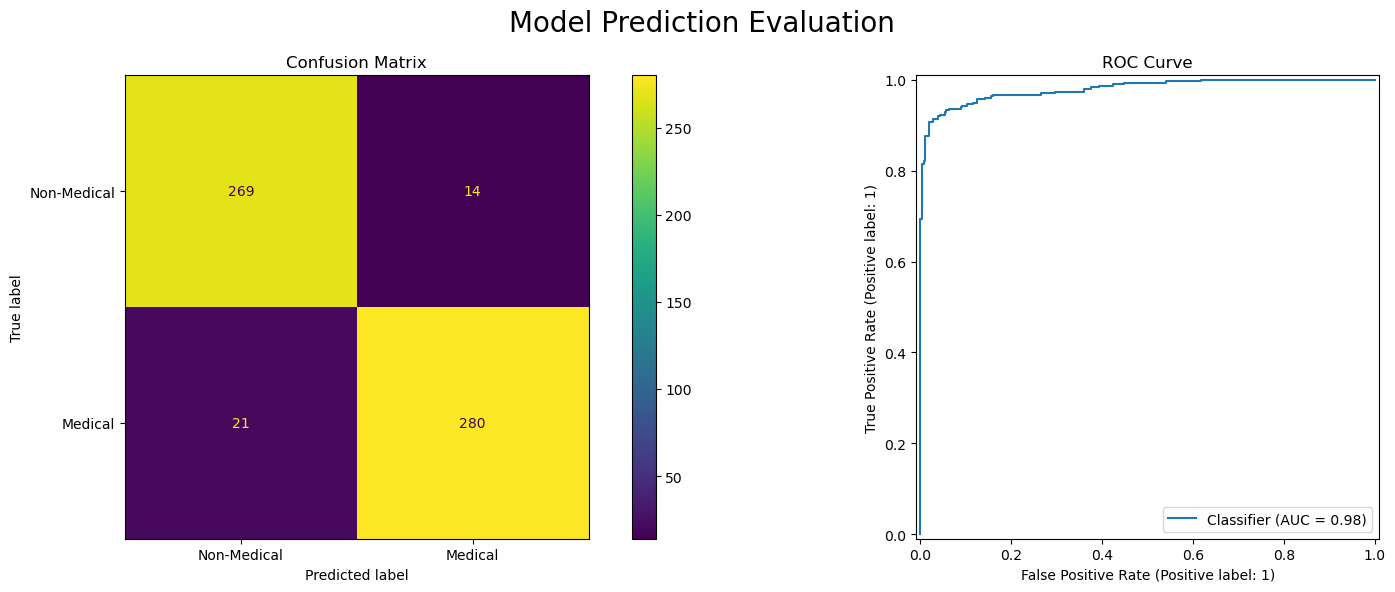

19/19 [==============================] - 0s 359us/step
Predictions - Non-Medical: 294 out of 584
Predictions - Misclassified: 35 out of 584
Example Misclassifications


,query,query-label-expert,query-is-non-medical-actual,query-is-non-medical-predicted
38,How close to death was I?,1,False,True
59,ELI5 How Name Brand Medications And Other Prod...,999,True,False
60,Why does my scalp get itchy when I eat spicy f...,999,True,False
64,What circumstances make death instant?,1,False,True
68,"Nurses/doctors of reddit, what is the most hum...",999,True,False
77,Is the book Wheat Belly pseudoscience?,999,True,False
83,How can I gain weight?,1,False,True
104,What is blood pressure ?,1,False,True
108,What would cause charlie horses in feet when y...,1,False,True
119,Why am I not taller?,1,False,True


19/19 [==============================] - 0s 579us/step

------------------------------------------------
Evaluation Results for: medical_question_classifier_tuned on clean data
Recall (Sensitivity, TP Rate): 0.9203
Precision: 0.9552
F1 Score 0.9374
Specificity (1 - Fall-Out): 0.9541
MCC: 0.8739
-----------
Accuracy: 0.9366
Fall Out (FPR): 0.0459
Hamming Loss 0.0634
ROC-AUC Score 0.9817
Gini Index: 0.9635
---------------------------------------------


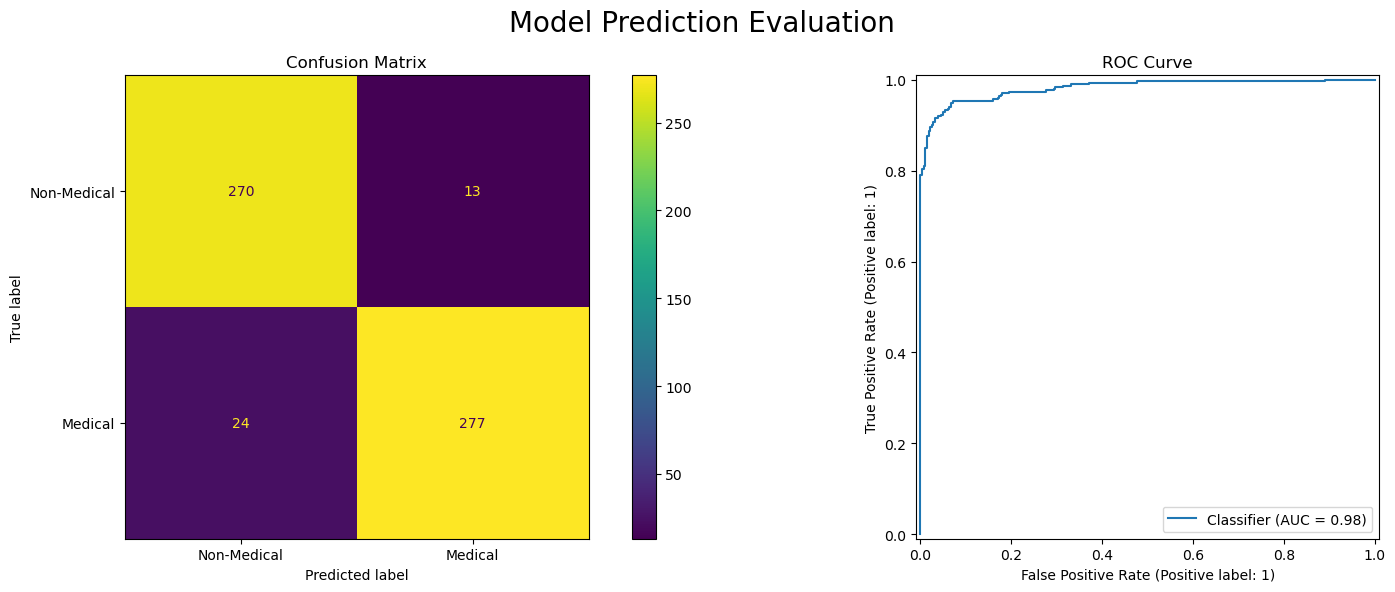

19/19 [==============================] - 0s 355us/step
Predictions - Non-Medical: 290 out of 584
Predictions - Misclassified: 37 out of 584
Example Misclassifications


,query,query-label-expert,query-is-non-medical-actual,query-is-non-medical-predicted
38,How close to death was I?,1,False,True
56,Random question - what's this little piece of ...,999,True,False
59,ELI5 How Name Brand Medications And Other Prod...,999,True,False
60,Why does my scalp get itchy when I eat spicy f...,999,True,False
64,What circumstances make death instant?,1,False,True
77,Is the book Wheat Belly pseudoscience?,999,True,False
82,How much would you trust the info on treadmill...,1,False,True
83,How can I gain weight?,1,False,True
104,What is blood pressure ?,1,False,True
108,What would cause charlie horses in feet when y...,1,False,True


Model Results Comparisons


,run_name,model_name,data_source,prediction_time,accuracy,mcc,recall,precision,specificity,f1_score
0,Test_Run_2,medical_question_classifier,clean,0.217663,0.940068,0.880365,0.930233,0.952381,0.950530,0.941176
1,Test_Run_2,medical_question_classifier_tuned,clean,0.060190,0.936644,0.873934,0.920266,0.955172,0.954064,0.937394


In [14]:
# Evaluate and Compare Models and Save Predictions

# Get predictions and evaluation metrics
# Map Predictions back to original query text

models_comparisons_df = pd.DataFrame()

model_results = evaluate_model(base_model, X_test, y_test, run_name)
models_comparisons_df = pd.concat([models_comparisons_df, pd.DataFrame([model_results])], ignore_index=True)
query_predictions_base_model_df = query_predictions(query_df, ids_test, X_test, base_model)
compare_predictions(query_predictions_base_model_df)
query_predictions_base_model_df.to_pickle(run_results_folder.joinpath('base_model_query_predictions.pkl'))

model_results = evaluate_model(tuned_model, X_test, y_test, run_name)
models_comparisons_df = pd.concat([models_comparisons_df, pd.DataFrame([model_results])], ignore_index=True)
query_predictions_tuned_model_df = query_predictions(query_df, ids_test, X_test, tuned_model)
compare_predictions(query_predictions_tuned_model_df)
query_predictions_tuned_model_df.to_pickle(run_results_folder.joinpath('tuned_model_query_predictions.pkl'))

# Show Models Comparision & Save
print('Model Results Comparisons')
display(models_comparisons_df)
models_comparisons_df.to_pickle(run_results_folder.joinpath('models_comparisons.pkl'))


***
# Adversarial Attacks Generation - PGD

## Hyperrectangle & PGD Functions

In [15]:
# Create random hyperrectangles based on embeddings
#

# TODO: Really not sure if this is a valid way to generate a hyperrectangle??

def generate_hyperrectangles(embedding_data, num_rectangles):

    # Min and max bounds for each dimension
    min_bounds = np.min(embedding_data, axis=0)
    max_bounds = np.max(embedding_data, axis=0)
    dimensions_num = len(min_bounds)
    print(f'Hyperrectangles Creation - Embeddings dimensions: {dimensions_num}')
    
    # Create hyperrectangles, with random bounds
    hyperrectangles = np.empty((num_rectangles, dimensions_num, 2))

    for rect_idx in range(num_rectangles):
        lower = min_bounds + np.random.random(dimensions_num) * (max_bounds - min_bounds) * 0.5
        upper = lower + np.random.random(dimensions_num) * (max_bounds - lower) * 0.9

        for dim_idx in range(dimensions_num):
            hyperrectangles[rect_idx, dim_idx] = [lower[dim_idx], upper[dim_idx]]
    
    # hyperrectangles = np.array(hyperrectangles)
    print(f'Hyperrectangles Creation - shape: {hyperrectangles.shape}')

    return hyperrectangles


In [16]:
# Core PGD Attack Generation - Using Hyperrectangles
#

# TODO: Review approach below, is it sufficient?

def pgd_attack_batch(model, X_batch, y_batch, pgd_steps, eps, gamma):
    """
    Performs PGD attack on a batch of inputs.

    Args:
        model: The model to attack.
        x_batch: Batch of input data.
        y_batch: Batch of true labels.
        pgd_steps: Number of PGD steps.
        eps: Tuple containing (lower bounds, upper bounds) for each dimension from hyperrectangles.
        gamma: Step size for each PGD iteration.

    Returns:
        perturbed_x: Adversarial examples generated from the input batch.
    """

    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    # Make a copy of the input to avoid modifying the original data
    X_adv = tf.identity(X_batch)
    
    # Iterate through the PGD steps
    for _ in range(pgd_steps):
        # Forward pass - calc loss and retain in tape
        with tf.GradientTape() as tape:
            tape.watch(X_adv)              # Records all operations, watches for gradient calc
            predictions = model(X_adv, training=False)
            loss = loss_fn(y_batch, predictions)
            # loss = tf.keras.losses.sparse_categorical_crossentropy(y_batch, predictions)
        
        # Compute gradient of the loss w.r.t the input
        gradients = tape.gradient(loss, X_adv)
        
        # Apply perturbation based on sign of the gradient
        # Perform gradient ascent step in the direction that maximizes the loss
        # TODO: Better understand how this maximises the loss?
        signed_grad = tf.sign(gradients)
        X_adv = X_adv + gamma * signed_grad

        # Project back within the epsilon bounds,
        # - the hyperrectangle with upper and lower bounds for each dimension
        # - keep to within 0 and 1
        X_adv = tf.clip_by_value(X_adv, eps[0], eps[1])
        # X_adv = tf.clip_by_value(X_adv, 0.0, 1.0) 
        # TODO: Is this appropriate for embedding vectors that may be outside these bounds??

    return X_adv

In [17]:
# Generate PGD dataset for use in model training
#

# TODO: This is as per Marco's NLP code but NOT ANTONIO

def generate_PGD_dataset(X, y, model, pgd_steps, gamma_multiplier):

    num_rectangles = len(X) # TODO: How many rectangles .... one each query?
    pgd_dataset = []
    pgd_labels = []

    # Generate hyperrectangles and combine into a tf dataset
    hyperrectangles = generate_hyperrectangles(X, num_rectangles)       # simple set of hyperrectangles: n * dimensions with upper/lower bounds
    hyperrectangles_labels = y
    hyperrectangles = tf.convert_to_tensor(hyperrectangles, dtype=tf.float32)
    # hyperrectangles_labels = tf.convert_to_tensor(hyperrectangles_labels, dtype=tf.int64)

    for i, hyperrectangle in enumerate(hyperrectangles):
        # For each dimension, get eps: the hyperrectangle lower and ipper bounds
        eps = tf.transpose(hyperrectangle)   
        gamma = tf.expand_dims((eps[1] - eps[0]) / (pgd_steps * gamma_multiplier), axis=0)  # Step-size within the bounds

        # Generate random points in hyperrectangles
        pgd_point = tf.random.uniform(shape=[1, eps.shape[-1]], minval=eps[0],maxval=eps[1])
        pgd_label = tf.expand_dims(hyperrectangles_labels[i], axis=0)

        # Generate the PGD attacks
        pgd_point = pgd_attack_batch(model, pgd_point, pgd_label, pgd_steps, eps, gamma)
        if len(pgd_dataset) > 0:
            pgd_dataset = tf.concat([pgd_dataset, pgd_point], axis=0)
            pgd_labels = tf.concat([pgd_labels, pgd_label], axis=0)
        else:
            pgd_dataset = pgd_point
            pgd_labels = pgd_label

    # Convert into tf datasets, shuffle and batch them
    pgd_dataset_tf = tf.data.Dataset.from_tensor_slices((pgd_dataset, pgd_labels))
    pgd_dataset_tf = pgd_dataset_tf.shuffle(buffer_size=1024).batch(batch_size)

    return pgd_dataset_tf


## Generate PGD Attack Examples & Attack Models

In [18]:
# Generate PGD attacks examples using hyperrectangles from the X data
#

# TODO: Impact of attack varies with Gamma and also the hyperrectangle chosen
# TODO: How to generate random vectors within bounds?

pgd_steps = 10
num_rectangles = len(X_test) # TODO: How many rectangles to define?? Just 1??
gamma_multiplier = 750       # TODO: Higher Gamma increases strength, eg 75- high FPs

# Create a simple set of hyperrectangles: n * dimensions with upper/lower bounds
#
hyperrectangles = generate_hyperrectangles(X_test, num_rectangles)
# TODO: Not clear what Y labels to use?, ANTONIO appears to set as 0......
# hyperrectangles_labels = np.full(len(hyperrectangles), 0)
hyperrectangles_labels = y_test
# hyperrectangles_labels = 1 - y_test # Targeted attack, flip lablels

# For example, load the hyper-rectangles - Marco's
# mc_hyperrectangles = np.load(run_results_folder.joinpath('marco_hyperrectangles.npy'))
# mc_hyperrectangles_labels = np.full(len(hyperrectangles), 0)

# Set the bounds
# TODO: Which hyperrectangle to select?
rectangle_idx = 0
eps = tf.transpose(hyperrectangles[rectangle_idx])   # For each dimension, the hyperrectangle lower and ipper bounds
gamma = tf.expand_dims((eps[1] - eps[0]) / (pgd_steps * gamma_multiplier), axis=0)  # Step-size within the bounds

# Generate a adversarial attack examples - based on the X_text embeddings & standard models
X_test_adv_base = pgd_attack_batch(base_model, X_test, y_test, pgd_steps, eps, gamma)
X_test_adv_tuned = pgd_attack_batch(tuned_model, X_test, y_test, pgd_steps, eps, gamma)

Hyperrectangles Creation - Embeddings dimensions: 30
Hyperrectangles Creation - shape: (584, 30, 2)


19/19 [==============================] - 0s 364us/step

------------------------------------------------
Evaluation Results for: medical_question_classifier on PGD_Base data
Recall (Sensitivity, TP Rate): 1.0000
Precision: 0.5154
F1 Score 0.6802
Specificity (1 - Fall-Out): 0.0000
MCC: 0.0000
-----------
Accuracy: 0.5154
Fall Out (FPR): 1.0000
Hamming Loss 0.4846
ROC-AUC Score 0.7570
Gini Index: 0.5139
---------------------------------------------


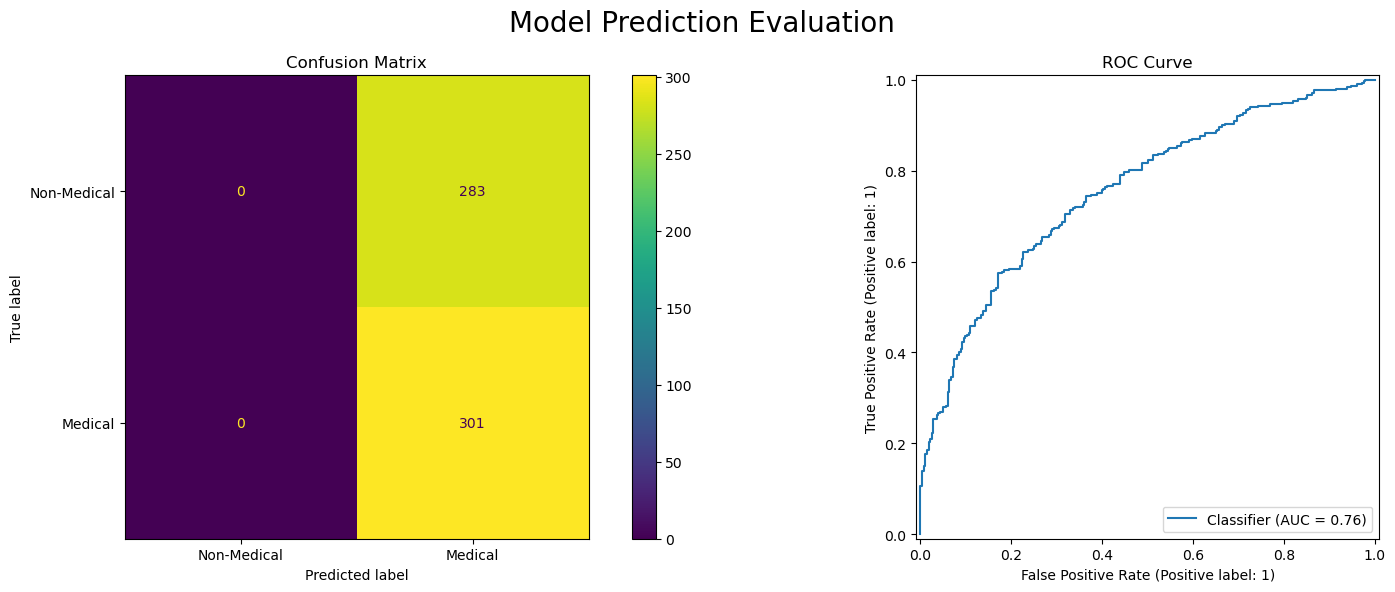

19/19 [==============================] - 0s 446us/step

------------------------------------------------
Evaluation Results for: medical_question_classifier_tuned on PGD_Tuned data
Recall (Sensitivity, TP Rate): 1.0000
Precision: 0.5154
F1 Score 0.6802
Specificity (1 - Fall-Out): 0.0000
MCC: 0.0000
-----------
Accuracy: 0.5154
Fall Out (FPR): 1.0000
Hamming Loss 0.4846
ROC-AUC Score 0.7184
Gini Index: 0.4368
---------------------------------------------


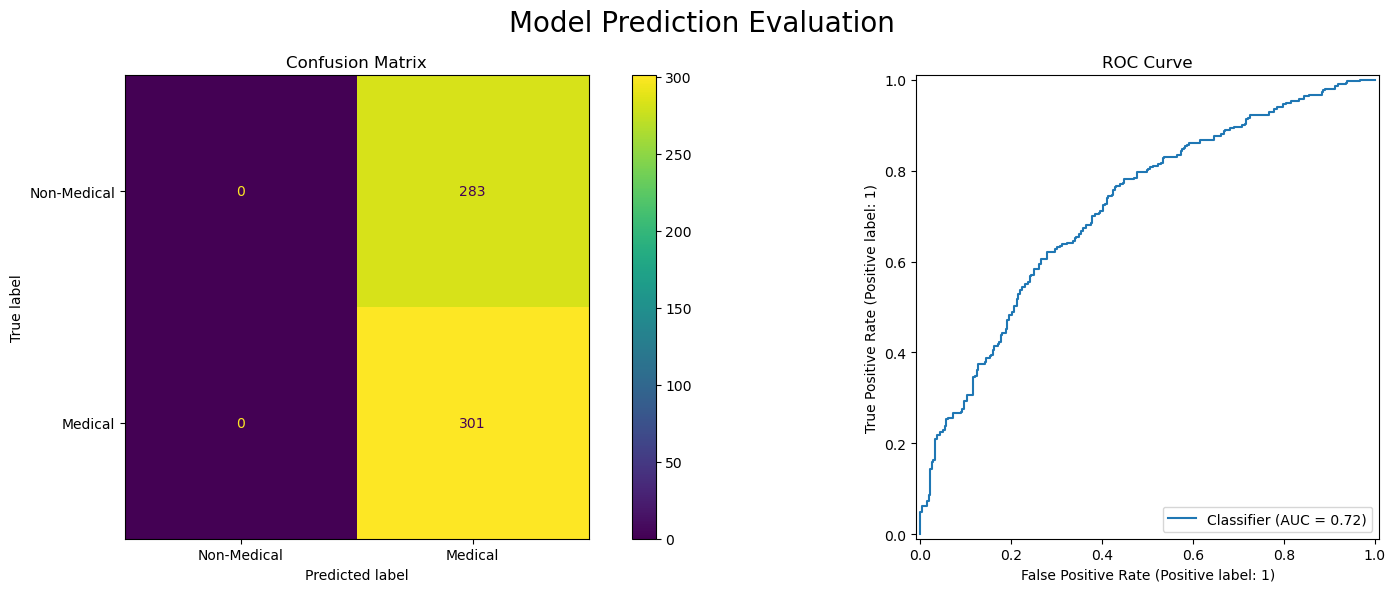

19/19 [==============================] - 0s 385us/step

------------------------------------------------
Evaluation Results for: medical_question_classifier on PGD_Tuned data
Recall (Sensitivity, TP Rate): 1.0000
Precision: 0.5154
F1 Score 0.6802
Specificity (1 - Fall-Out): 0.0000
MCC: 0.0000
-----------
Accuracy: 0.5154
Fall Out (FPR): 1.0000
Hamming Loss 0.4846
ROC-AUC Score 0.7585
Gini Index: 0.5169
---------------------------------------------


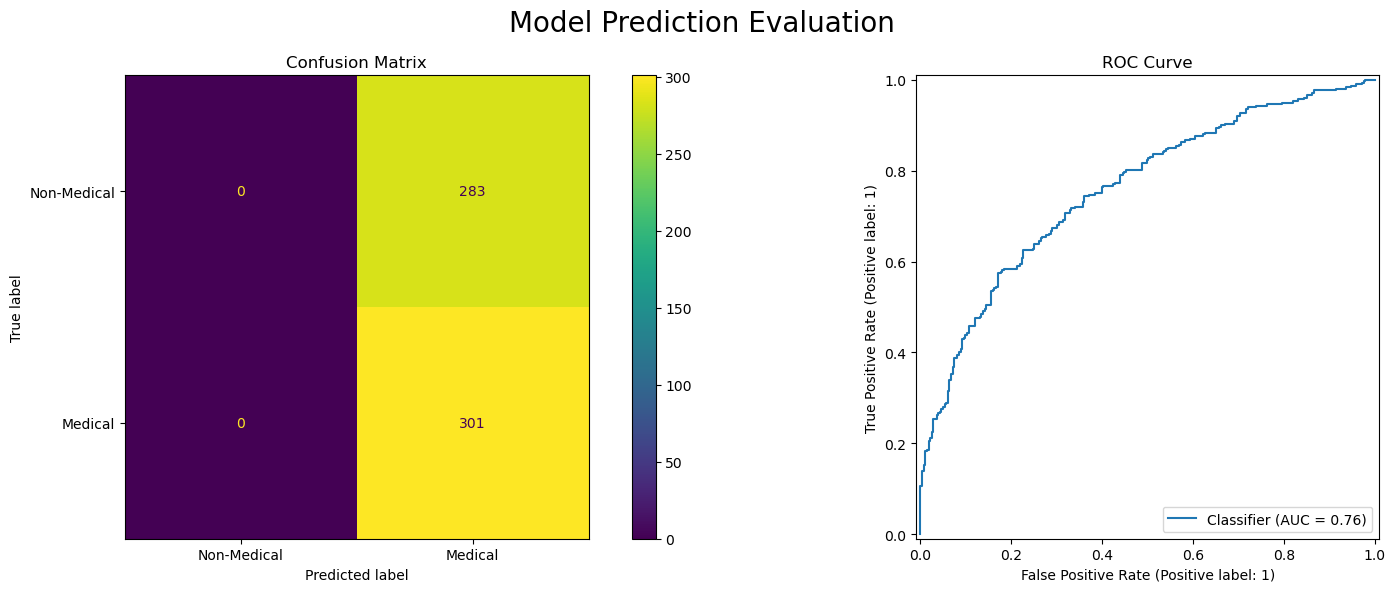

19/19 [==============================] - 0s 374us/step

------------------------------------------------
Evaluation Results for: medical_question_classifier_tuned on PGD_Base data
Recall (Sensitivity, TP Rate): 1.0000
Precision: 0.5154
F1 Score 0.6802
Specificity (1 - Fall-Out): 0.0000
MCC: 0.0000
-----------
Accuracy: 0.5154
Fall Out (FPR): 1.0000
Hamming Loss 0.4846
ROC-AUC Score 0.7215
Gini Index: 0.4430
---------------------------------------------


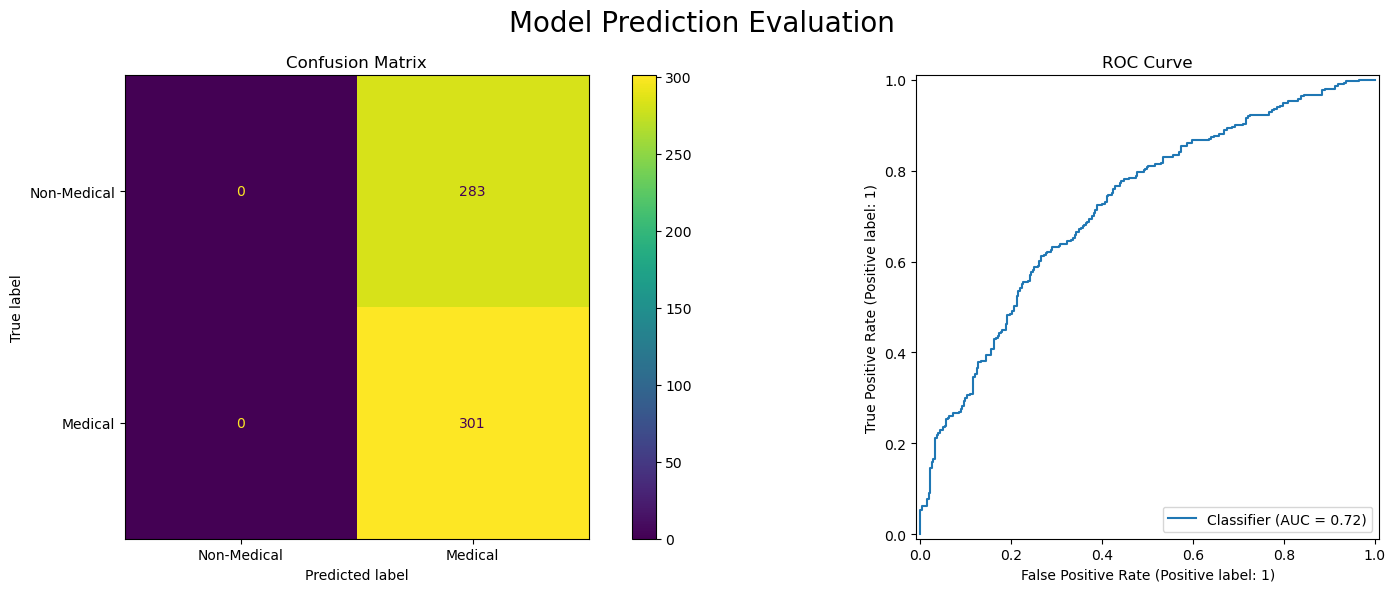

Model Results Comparisons


,run_name,model_name,data_source,prediction_time,accuracy,mcc,recall,precision,specificity,f1_score
0,Test_Run_2,medical_question_classifier,clean,0.217663,0.940068,0.880365,0.930233,0.952381,0.950530,0.941176
1,Test_Run_2,medical_question_classifier_tuned,clean,0.060190,0.936644,0.873934,0.920266,0.955172,0.954064,0.937394
2,Test_Run_2,medical_question_classifier,PGD_Base,0.058687,0.515411,0.000000,1.000000,0.515411,0.000000,0.680226
3,Test_Run_2,medical_question_classifier_tuned,PGD_Tuned,0.057868,0.515411,0.000000,1.000000,0.515411,0.000000,0.680226
4,Test_Run_2,medical_question_classifier,PGD_Tuned,0.035786,0.515411,0.000000,1.000000,0.515411,0.000000,0.680226
5,Test_Run_2,medical_question_classifier_tuned,PGD_Base,0.036955,0.515411,0.000000,1.000000,0.515411,0.000000,0.680226


In [19]:
# PGD Attack on Base Models & Compare
# Add to comparisons df
#

model_results = evaluate_model(base_model, X_test_adv_base, y_test, run_name, data_source='PGD_Base')
models_comparisons_df = pd.concat([models_comparisons_df, pd.DataFrame([model_results])], ignore_index=True)

model_results = evaluate_model(tuned_model, X_test_adv_tuned, y_test, run_name, data_source='PGD_Tuned')
models_comparisons_df = pd.concat([models_comparisons_df, pd.DataFrame([model_results])], ignore_index=True)

model_results = evaluate_model(base_model, X_test_adv_tuned, y_test, run_name, data_source='PGD_Tuned')
models_comparisons_df = pd.concat([models_comparisons_df, pd.DataFrame([model_results])], ignore_index=True)

model_results = evaluate_model(tuned_model, X_test_adv_base, y_test, run_name, data_source='PGD_Base')
models_comparisons_df = pd.concat([models_comparisons_df, pd.DataFrame([model_results])], ignore_index=True)

# Show Models Comparision & Save
print('Model Results Comparisons')
display(models_comparisons_df)
models_comparisons_df.to_pickle(run_results_folder.joinpath('models_comparisons.pkl'))

# TODO: Attacks don't seem to be significantly disruptive ..... how to make stronger eg Gamma?


***
# Adversarial Model Training

## Model Training - Custom & PGD

In [ ]:
# Build Model - Custom Loop
#

# TODO: Not realy certain if implemented correctly?

def build_model_custom(model, epochs, train_dataset, val_dataset, loss_fn, optimizer, eval_metric, loss_metric, alpha, beta):

    # TODO: NB using same loss function and metrics for clean and PGD training

    epochs = 50
    # batch_size = 64
    pgd_steps = 5
    gamma_multiplier = 1000
    # alpha = 0.7
    # beta = 0.3

    eval_metric_val = copy.deepcopy(eval_metric)
    eval_metric_pgd = copy.deepcopy(eval_metric)
    loss_metric_pgd = copy.deepcopy(loss_metric)

    # Train for each epoch
    for epoch in range(epochs):
        start_time = time.time()
        print(f"Epoch {epoch + 1} of {epochs}. ")
        eval_metric.reset_states()
        eval_metric_val.reset_states()
        eval_metric_pgd.reset_states()
        loss_metric.reset_states()
        loss_metric_pgd.reset_states()

        # 1. Clean X training - For each batch in the datset
        for step, (X_batch, y_batch) in enumerate(train_dataset):
            # Forward pass - calc loss and retain in tape
            with tf.GradientTape() as tape:
                logits = model(X_batch, training=True)
                loss = loss_fn(y_batch, logits) * alpha
            
            # Backpropagate - gradient descent and optimised model weights
            gradients = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))

            # Update metrics
            loss_metric.update_state(y_batch, logits)
            eval_metric.update_state(y_batch, logits)

        # 2. PGD Attack Training
        if beta > 0:
            pgd_dataset = generate_PGD_dataset(X_batch, y_batch, model, pgd_steps, gamma_multiplier)

            for step, (X_batch, y_batch) in enumerate(pgd_dataset):
                print(f'PGD step: {step}')
                # Forward pass - calc loss and retain in tape
                with tf.GradientTape() as tape:
                    pgd_logits = model(X_batch, training=True)
                    pgd_loss = loss_fn(y_batch, pgd_logits) * beta

                # Backpropagate - gradient descent and optimised model weights
                pgd_gradients = tape.gradient(pgd_loss, model.trainable_variables)
                optimizer.apply_gradients(zip(pgd_gradients, model.trainable_variables))

                # Update metrics
                loss_metric_pgd.update_state(y_batch, pgd_logits)
                eval_metric_pgd.update_state(y_batch, pgd_logits)

        # End of epoch results

        # # Validation results calc
        # for X_val_batch, y_val_batch in val_dataset:
        #     val_logits = model(X_val_batch, training=False)
        #     eval_metric_val.update_state(y_val_batch, val_logits)
        #     loss_metric.update_state(y_val_batch, val_logits)

        metric_name = eval_metric.name
        metric_value = eval_metric.result().numpy()
        metric_pgd_value = eval_metric_pgd.result().numpy()
        # val_metric_value = eval_metric_val.result().numpy() 
        loss_metric_value = loss_metric.result().numpy()
        loss_metric_pgd_value = loss_metric_pgd.result().numpy() 

        elapsed_time = time.time() - start_time
        # print(f'Training: Loss: {loss_metric_value:4f} Metric: {metric_name} - Train: {metric_value:.4f} & Val: {val_metric_value:.4f} Time: {elapsed_time:.2f}s')
        print(f'Training Clean: Loss: {loss_metric_value:4f} Metric: {metric_name} - {metric_value:.4f} Time: {elapsed_time:.2f}s')
        print(f'Training PGD: Loss: {loss_metric_pgd_value:4f} Metric: {metric_name} - {metric_pgd_value:.4f} Time: {elapsed_time:.2f}s')

    return model


In [21]:
# Build & Train Model - Custom + Clean Data
#

# TODO: Change metrics to eg precision or MCC?

input_dimensions = embedding_dimensions
epochs = 30
model_name = 'medical_question_classifier_custom'
optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
eval_metric = tf.keras.metrics.SparseCategoricalAccuracy()
loss_metric = tf.keras.metrics.SparseCategoricalCrossentropy(from_logits=True)

alpha = 0.7
beta = 0    # No PGD datset, adversarial training

# Build and train the model
custom_model = build_model(input_dimensions)
custom_model._name = model_name
custom_model = build_model_custom(custom_model, epochs, train_dataset_tf, val_dataset_tf, loss_fn, optimizer, eval_metric, loss_metric, alpha, beta)

# Save Trained Model
custom_model.save(run_results_folder.joinpath('custom_model_trained.keras'))


Epoch 1 of 50. 
Training Clean: Loss: 0.670819 Metric: sparse_categorical_accuracy - 0.6381 Time: 0.18s
Training PGD: Loss: 0.000000 Metric: sparse_categorical_accuracy - 0.0000 Time: 0.18s
Epoch 2 of 50. 
Training Clean: Loss: 0.581333 Metric: sparse_categorical_accuracy - 0.9188 Time: 0.16s
Training PGD: Loss: 0.000000 Metric: sparse_categorical_accuracy - 0.0000 Time: 0.16s
Epoch 3 of 50. 
Training Clean: Loss: 0.483897 Metric: sparse_categorical_accuracy - 0.9428 Time: 0.16s
Training PGD: Loss: 0.000000 Metric: sparse_categorical_accuracy - 0.0000 Time: 0.16s
Epoch 4 of 50. 
Training Clean: Loss: 0.384631 Metric: sparse_categorical_accuracy - 0.9445 Time: 0.16s
Training PGD: Loss: 0.000000 Metric: sparse_categorical_accuracy - 0.0000 Time: 0.16s
Epoch 5 of 50. 
Training Clean: Loss: 0.302716 Metric: sparse_categorical_accuracy - 0.9434 Time: 0.16s
Training PGD: Loss: 0.000000 Metric: sparse_categorical_accuracy - 0.0000 Time: 0.16s
Epoch 6 of 50. 
Training Clean: Loss: 0.248341 Met

In [22]:
# Build & Train - Custom Model + PGD Data
#

input_dimensions = embedding_dimensions
epochs = 30
model_name = 'medical_question_classifier_PGD'
optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
eval_metric = tf.keras.metrics.SparseCategoricalAccuracy()
loss_metric = tf.keras.metrics.SparseCategoricalCrossentropy(from_logits=True)

alpha = 0.7
beta = 0.3

# Build and train the model
custom_model_pgd = build_model(input_dimensions)
custom_model_pgd._name = model_name
custom_model_pgd = build_model_custom(custom_model_pgd, epochs, train_dataset_tf, val_dataset_tf, loss_fn, optimizer, eval_metric, loss_metric, alpha, beta)

# Save Trained Model
custom_model_pgd.save(run_results_folder.joinpath('pgd_model_trained.keras'))


Epoch 1 of 50. 
Hyperrectangles Creation - Embeddings dimensions: 30
Hyperrectangles Creation - shape: (21, 30, 2)


2025-10-05 14:36:27.846728: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [21]
	 [[{{node Placeholder/_1}}]]
2025-10-05 14:36:27.846879: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [21]
	 [[{{node Placeholder/_1}}]]


PGD step: 0
Training Clean: Loss: 0.668547 Metric: sparse_categorical_accuracy - 0.6701 Time: 0.52s
Training PGD: Loss: 0.695163 Metric: sparse_categorical_accuracy - 0.4286 Time: 0.52s
Epoch 2 of 50. 
Hyperrectangles Creation - Embeddings dimensions: 30
Hyperrectangles Creation - shape: (21, 30, 2)


2025-10-05 14:36:28.321127: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [21]
	 [[{{node Placeholder/_1}}]]
2025-10-05 14:36:28.321297: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [21]
	 [[{{node Placeholder/_1}}]]


PGD step: 0
Training Clean: Loss: 0.576011 Metric: sparse_categorical_accuracy - 0.9331 Time: 0.47s
Training PGD: Loss: 0.678149 Metric: sparse_categorical_accuracy - 0.6190 Time: 0.47s
Epoch 3 of 50. 
Hyperrectangles Creation - Embeddings dimensions: 30
Hyperrectangles Creation - shape: (21, 30, 2)


...

2025-10-05 14:36:47.345982: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype float and shape [21,30]
	 [[{{node Placeholder/_0}}]]
2025-10-05 14:36:47.346133: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [21]
	 [[{{node Placeholder/_1}}]]


PGD step: 0
Training Clean: Loss: 0.103770 Metric: sparse_categorical_accuracy - 0.9640 Time: 0.40s
Training PGD: Loss: 1.008721 Metric: sparse_categorical_accuracy - 0.5238 Time: 0.40s
Epoch 49 of 50. 
Hyperrectangles Creation - Embeddings dimensions: 30
Hyperrectangles Creation - shape: (21, 30, 2)


2025-10-05 14:36:47.743792: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [21]
	 [[{{node Placeholder/_1}}]]
2025-10-05 14:36:47.743959: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [21]
	 [[{{node Placeholder/_1}}]]


PGD step: 0
Training Clean: Loss: 0.102763 Metric: sparse_categorical_accuracy - 0.9646 Time: 0.40s
Training PGD: Loss: 1.535922 Metric: sparse_categorical_accuracy - 0.4762 Time: 0.40s
Epoch 50 of 50. 
Hyperrectangles Creation - Embeddings dimensions: 30
Hyperrectangles Creation - shape: (21, 30, 2)
PGD step: 0
Training Clean: Loss: 0.101057 Metric: sparse_categorical_accuracy - 0.9657 Time: 0.44s
Training PGD: Loss: 0.979187 Metric: sparse_categorical_accuracy - 0.5714 Time: 0.44s


2025-10-05 14:36:48.189302: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [21]
	 [[{{node Placeholder/_1}}]]
2025-10-05 14:36:48.189453: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [21]
	 [[{{node Placeholder/_1}}]]


19/19 [==============================] - 0s 466us/step

------------------------------------------------
Evaluation Results for: medical_question_classifier_custom on clean data
Recall (Sensitivity, TP Rate): 0.9169
Precision: 0.9617
F1 Score 0.9388
Specificity (1 - Fall-Out): 0.9611
MCC: 0.8778
-----------
Accuracy: 0.9384
Fall Out (FPR): 0.0389
Hamming Loss 0.0616
ROC-AUC Score 0.9800
Gini Index: 0.9600
---------------------------------------------


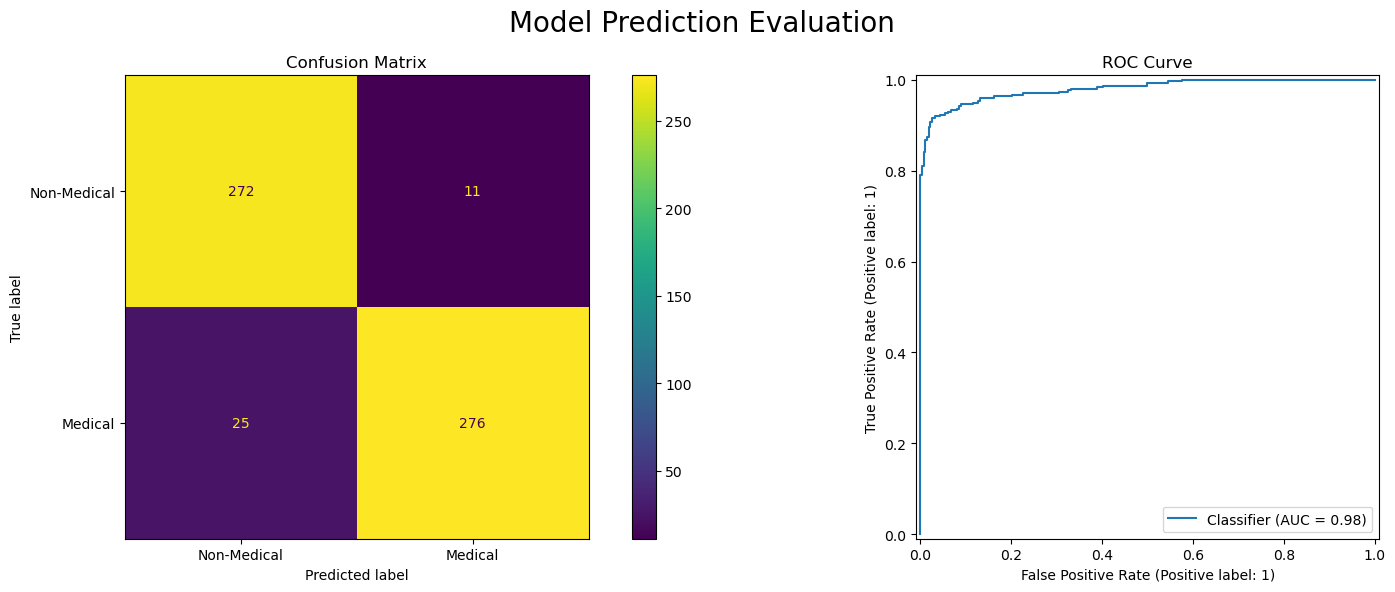

19/19 [==============================] - 0s 593us/step

------------------------------------------------
Evaluation Results for: medical_question_classifier_PGD on clean data
Recall (Sensitivity, TP Rate): 0.9203
Precision: 0.9652
F1 Score 0.9422
Specificity (1 - Fall-Out): 0.9647
MCC: 0.8846
-----------
Accuracy: 0.9418
Fall Out (FPR): 0.0353
Hamming Loss 0.0582
ROC-AUC Score 0.9806
Gini Index: 0.9613
---------------------------------------------


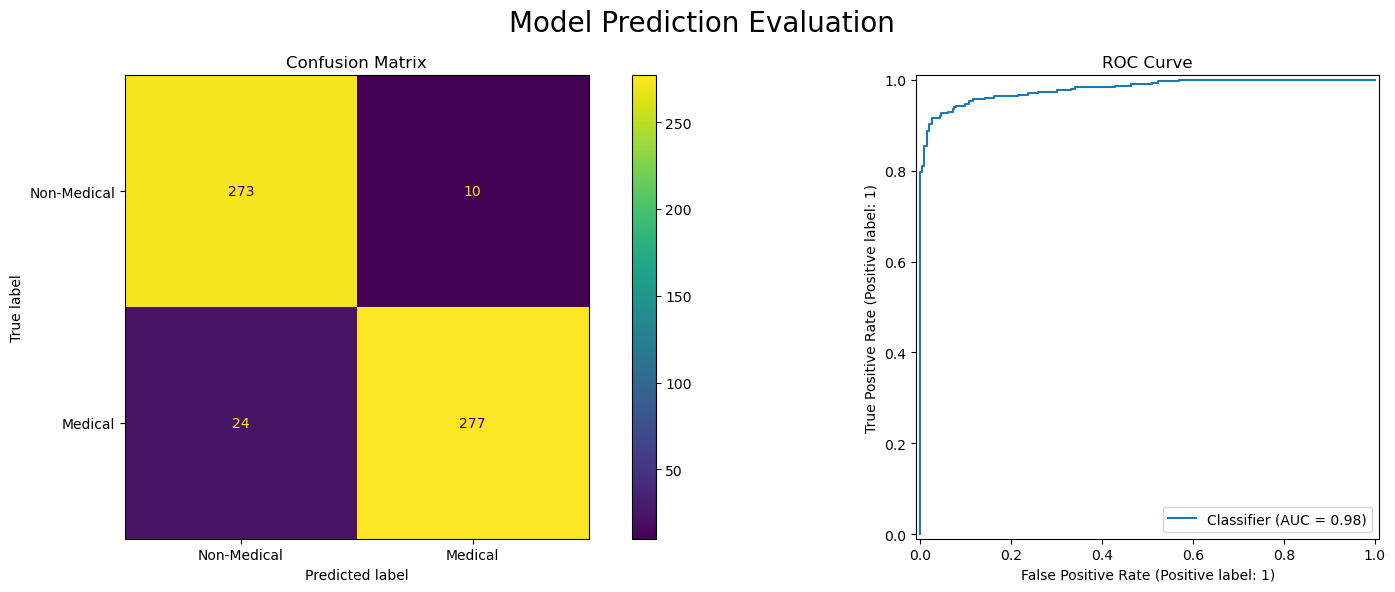

19/19 [==============================] - 0s 854us/step

------------------------------------------------
Evaluation Results for: medical_question_classifier_custom on PGD_Base data
Recall (Sensitivity, TP Rate): 1.0000
Precision: 0.5154
F1 Score 0.6802
Specificity (1 - Fall-Out): 0.0000
MCC: 0.0000
-----------
Accuracy: 0.5154
Fall Out (FPR): 1.0000
Hamming Loss 0.4846
ROC-AUC Score 0.7716
Gini Index: 0.5431
---------------------------------------------


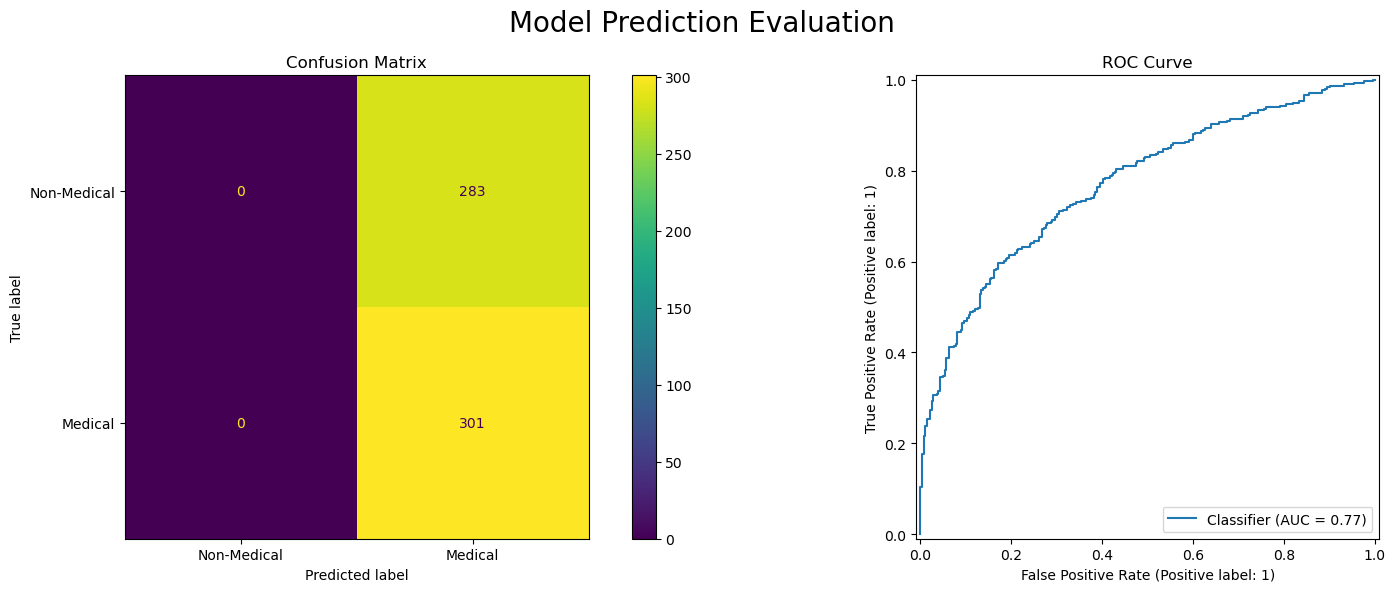

19/19 [==============================] - 0s 411us/step

------------------------------------------------
Evaluation Results for: medical_question_classifier_PGD on PGD_Tuned data
Recall (Sensitivity, TP Rate): 1.0000
Precision: 0.5154
F1 Score 0.6802
Specificity (1 - Fall-Out): 0.0000
MCC: 0.0000
-----------
Accuracy: 0.5154
Fall Out (FPR): 1.0000
Hamming Loss 0.4846
ROC-AUC Score 0.7834
Gini Index: 0.5667
---------------------------------------------


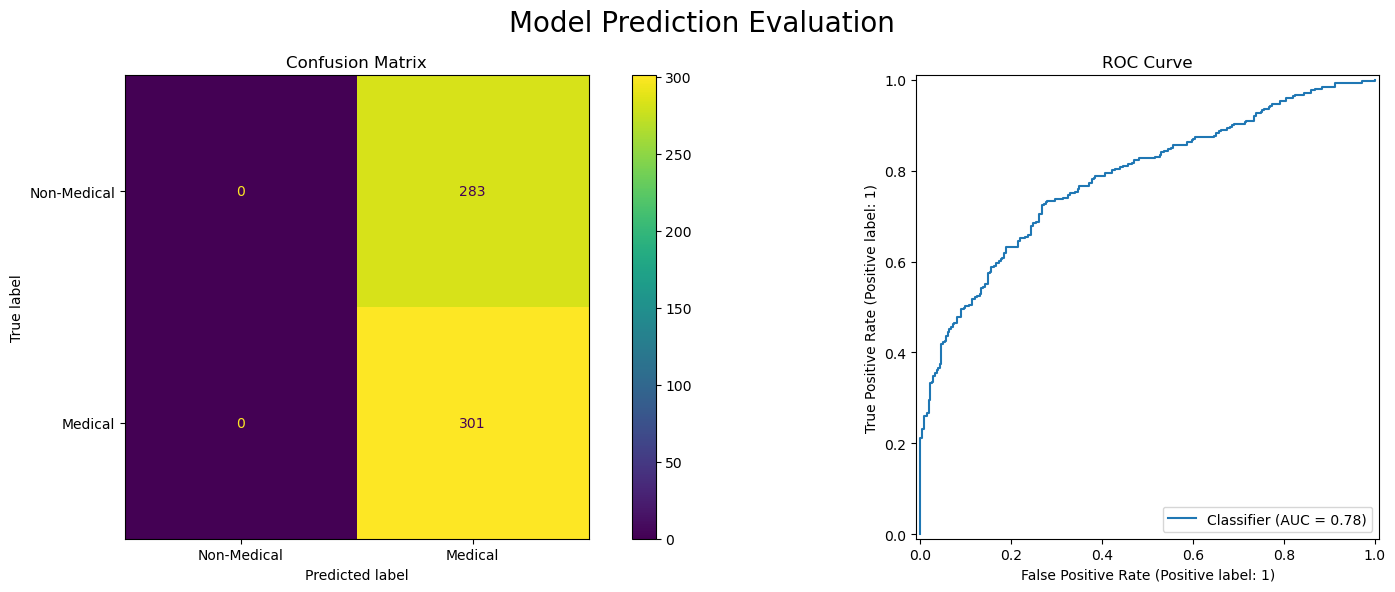

Model Results Comparisons


,run_name,model_name,data_source,prediction_time,accuracy,mcc,recall,precision,specificity,f1_score
0,Test_Run_2,medical_question_classifier,clean,0.217663,0.940068,0.880365,0.930233,0.952381,0.950530,0.941176
1,Test_Run_2,medical_question_classifier_tuned,clean,0.060190,0.936644,0.873934,0.920266,0.955172,0.954064,0.937394
2,Test_Run_2,medical_question_classifier,PGD_Base,0.058687,0.515411,0.000000,1.000000,0.515411,0.000000,0.680226
3,Test_Run_2,medical_question_classifier_tuned,PGD_Tuned,0.057868,0.515411,0.000000,1.000000,0.515411,0.000000,0.680226
4,Test_Run_2,medical_question_classifier,PGD_Tuned,0.035786,0.515411,0.000000,1.000000,0.515411,0.000000,0.680226
5,Test_Run_2,medical_question_classifier_tuned,PGD_Base,0.036955,0.515411,0.000000,1.000000,0.515411,0.000000,0.680226
6,Test_Run_2,medical_question_classifier_custom,clean,0.077009,0.938356,0.877786,0.916944,0.961672,0.961131,0.938776
7,Test_Run_2,medical_question_classifier_PGD,clean,0.065982,0.941781,0.884639,0.920266,0.965157,0.964664,0.942177
8,Test_Run_2,medical_question_classifier_custom,PGD_Base,0.144234,0.515411,0.000000,1.000000,0.515411,0.000000,0.680226
9,Test_Run_2,medical_question_classifier_PGD,PGD_Tuned,0.058902,0.515411,0.000000,1.000000,0.515411,0.000000,0.680226


In [23]:
# Evaluate Models & Compare
#

# Custom Models - Clean
model_results = evaluate_model(custom_model, X_test, y_test, run_name, data_source='clean')
models_comparisons_df = pd.concat([models_comparisons_df, pd.DataFrame([model_results])], ignore_index=True)

model_results = evaluate_model(custom_model_pgd, X_test, y_test, run_name, data_source='clean')
models_comparisons_df = pd.concat([models_comparisons_df, pd.DataFrame([model_results])], ignore_index=True)

# Custom Model - PGD Attacks
model_results = evaluate_model(custom_model, X_test_adv_base, y_test, run_name, data_source='PGD_Base')
models_comparisons_df = pd.concat([models_comparisons_df, pd.DataFrame([model_results])], ignore_index=True)

model_results = evaluate_model(custom_model_pgd, X_test_adv_tuned, y_test, run_name, data_source='PGD_Tuned')
models_comparisons_df = pd.concat([models_comparisons_df, pd.DataFrame([model_results])], ignore_index=True)

# Show Models Comparision & Save
print('Model Results Comparisons')
display(models_comparisons_df)
models_comparisons_df.to_pickle(run_results_folder.joinpath('models_comparisons.pkl'))
